Saving Lights_of_Rockefeller_Center_during_sunset.jpg to Lights_of_Rockefeller_Center_during_sunset.jpg


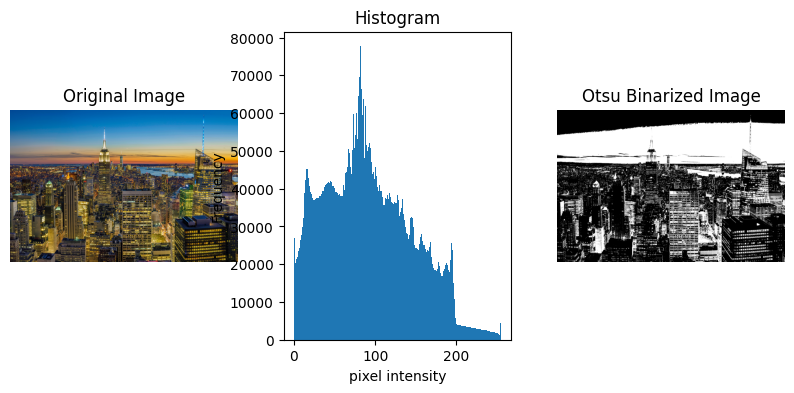

In [ ]:

# Import required libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Upload image
uploaded = files.upload()

# Get uploaded file name
image_path = list(uploaded.keys())[0]

# Read image in grayscale
img = cv2.imread(image_path, 0)

# Read image in BGR (for display)
img_bgr = cv2.imread(image_path)

# Check if image is loaded
if img is None or img_bgr is None:
    raise ValueError("Failed to load image!")

# Convert BGR to RGB for correct display
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Apply Otsu's Binarization
# Threshold value is automatically calculated
_, otsu = cv2.threshold(
    img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# Display results
plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(img_rgb)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Histogram")
plt.hist(  img.ravel(), 256)
plt.xlabel("pixel intensity")
plt.ylabel("Frequency")

plt.subplot(1,3,3)
plt.title("Otsu Binarized Image")
plt.imshow(otsu, cmap="gray")
plt.axis("off")

plt.show()




Saving Lights_of_Rockefeller_Center_during_sunset.jpg to Lights_of_Rockefeller_Center_during_sunset (1).jpg
Image loaded: Lights_of_Rockefeller_Center_during_sunset (1).jpg


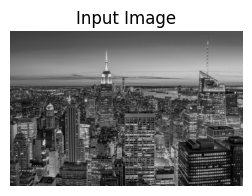

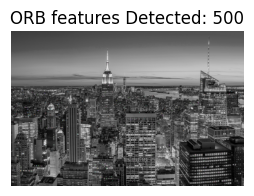

ORB Descriptor Shape: (500, 32)


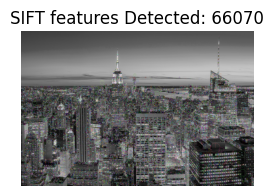

SIFT Descriptor Shape: (66070, 128)
X SURF not supported (Patent restriction in OpenCV)
===== FEATURE EXTRACTION SUMMARY =====
ORB features: 500
SIFT features: 66070


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2



import cv2
import matplotlib.pyplot as plt
from google.colab import files
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
print("Image loaded:", image_path)

# Load the image in color first, as cv2.cvtColor expects a 3-channel image
original_img = cv2.imread(image_path)

# Check if the image was loaded successfully
if original_img is None:
    raise ValueError(f"Failed to load image from {image_path}! Please check the path and ensure it's a valid image file.")

gray = cv2.cvtColor(original_img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(3,3))
plt.imshow(gray, cmap='gray')
plt.title("Input Image")
plt.axis("off")
plt.show()

orb = cv2.ORB_create(nfeatures=500)
kp_orb, des_orb = orb.detectAndCompute(gray, None)
orb_img = cv2.drawKeypoints(gray, kp_orb, None, flags=cv2.DRAW_MATCHES_FLAGS_DEFAULT)
plt.figure(figsize=(3,3))
plt.imshow(orb_img, cmap='gray')
plt.title(f"ORB features Detected: {len(kp_orb)}")
plt.axis("off")
plt.show()
print("ORB Descriptor Shape:", des_orb.shape)
sift = cv2.SIFT_create()
kp_sift, des_sift = sift.detectAndCompute(gray, None)
sift_img = cv2.drawKeypoints(gray, kp_sift, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.figure(figsize=(3,3))
plt.imshow(sift_img, cmap='gray')
plt.title(f"SIFT features Detected: {len(kp_sift)}")
plt.axis("off")
plt.show()
print("SIFT Descriptor Shape:", des_sift.shape)
try:
  surf = cv2.xfeatures2d.SURF_create(400)
  kp_surf, des_surf = surf.detectAndCompute(gray, None)
  surf_img = cv2.drawKeypoints(gray, kp_surf, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
  plt.figure(figsize=(3,3))
  plt.imshow(surf_img, cmap='gray')
  plt.title(f"SURF features Detected: {len(kp_surf)}")
  plt.axis("off")
  plt.show()
  print("SURF Descriptor Shape:", des_surf.shape)
except:
  print("X SURF not supported (Patent restriction in OpenCV)")
  print("===== FEATURE EXTRACTION SUMMARY =====")
  print("ORB features:", len(kp_orb))
  print("SIFT features:", len(kp_sift))


Total number of images (X): 1797
Total number of labels (Y): 1797
SVC training completed.
Accuracy: 0.8166666666666667


Saving Lights_of_Rockefeller_Center_during_sunset.jpg to Lights_of_Rockefeller_Center_during_sunset (2).jpg


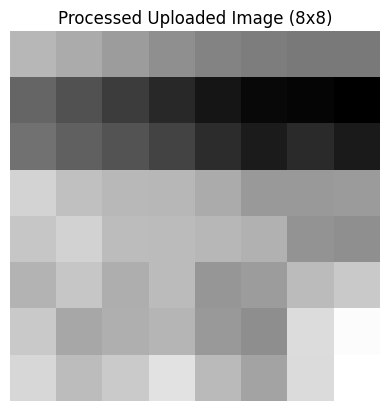

Predicted Digit: 5


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

from skimage.feature import hog
from skimage.transform import resize

digits = datasets.load_digits()
X = digits.images
y = digits.target
print("Total number of images (X):", X.shape[0])
print("Total number of labels (Y):", y.shape[0])

features = []
for img in X: # Corrected 'x' to 'X'
  hog_feature = hog(img, orientations=9, pixels_per_cell=(4,4), cells_per_block=(1,1))
  features.append(hog_feature)
features = np.array(features) # Moved out of loop

X_train, X_test, y_train, y_test = train_test_split(features, y, test_size=0.2, random_state=42)
model = SVC(kernel='linear') # Corrected 'Kernel' to 'kernel'
model.fit(X_train, y_train)
print("SVC training completed.")
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
from google.colab import files
uploaded = files.upload()

for file_name in uploaded.keys():
  img = cv2.imread(file_name)
  if img is None:
      print(f"Error: Could not load image {file_name}. Skipping.")
      continue

  if len(img.shape) == 3:
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  else:
    img_gray = img

  img_resized = resize(img_gray, (8,8), anti_aliasing=True)
  img_resized = img_resized / img_resized.max() # Normalize to 0-1 range
  img_resized = 1 - img_resized # Invert colors to match digits dataset (white digits on black background)

  plt.imshow(img_resized, cmap='gray')
  plt.title("Processed Uploaded Image (8x8)") # Corrected 'tittle' to 'title'
  plt.axis('off')
  plt.show()

  test_features = hog(img_resized, orientations=9, pixels_per_cell=(4,4), cells_per_block=(1,1))
  prediction = model.predict([test_features]) # Corrected 'test_feature' to 'test_features'
  print("Predicted Digit:", prediction[0])